# Module 6 - Programming Assignment

## Directions

1. Change the name of this file to be your JHED id as in `jsmith299.ipynb`. Because sure you use your JHED ID (it's made out of your name and not your student id which is just letters and numbers).
2. Make sure the notebook you submit is cleanly and fully executed. I do not grade unexecuted notebooks.
3. Submit your notebook back in Blackboard where you downloaded this file.

*Provide the output **exactly** as requested*

In [1]:
%matplotlib inline

from copy import deepcopy
from math import inf
from typing import Callable, Dict, List, Set, Tuple

import matplotlib.pyplot as plt
import networkx as nx


**For this assignment only**

If you want to use NetworkX with your assignment, you can do:

```
conda install networkx
```
or

```
pip install networkx
```

Additionally, this assignment uses a recursive algorithm. You should use `deecopy` at the appropriate places to avoid entanglement issues.

1. Follow the pseudocode in the book exactly.
2. Learn about the [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem).


These links are to help me navigate your notebook:

1. [Four Color Connecticut](#four_ct)
2. [Three Color Connecticut](#three_ct)
3. [Four Color Europe](#four_eu)
4. [Three Color Europe](#three_eu)


## CSP: Map Coloring

In this programming assignment, you will be using your new understanding of **Constraint Satisfaction Problems** to color maps. As we know from the [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem) any division of a plane into contiguous regions can be colored such that no two adjacent regions are the same color by using at most four colors.

From the book, we know that we can translate this problem into a CSP where the map is represented as a [planar graph](http://en.wikipedia.org/wiki/Planar_graph) and the goal is to color all the nodes such that no adjacent nodes are colored the same color.

As with most AI problems, this requires us to figure out how best to represent the problem--and the solution--given the high and low level data structures and types at our disposal. For this problem, we'll settle on a Dict which contains at least two keys: "nodes" which is an *ordered* List of Strings that represents each node or vertex in the planar graph and "edges" which contains a List of Tuples that represent edges between nodes. The Tuples are of ints that represent the index of the node in the "nodes" list.

Using this system, and adding a "coordinates" key with abstract drawing coordinates of each node for NetworkX, we can represent the counties of Connecticut like so:

In [2]:
# fmt: off
connecticut = {
    "coordinates": [(46, 52), (217, 146), (65, 142), (147, 85), (162, 140), (104, 77), (197, 94), (123, 142)],
    "edges": [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4), (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)],
    "nodes": ["Fairfield", "Windham", "Litchfield", "Middlesex", "Tolland", "New Haven", "New London", "Hartford"],
}
print(connecticut)
# fmt: on

{'coordinates': [(46, 52), (217, 146), (65, 142), (147, 85), (162, 140), (104, 77), (197, 94), (123, 142)], 'edges': [(0, 2), (0, 5), (2, 5), (2, 7), (5, 7), (5, 3), (7, 3), (7, 4), (7, 6), (3, 6), (4, 6), (4, 1), (6, 1)], 'nodes': ['Fairfield', 'Windham', 'Litchfield', 'Middlesex', 'Tolland', 'New Haven', 'New London', 'Hartford']}


The coordinates permit us to use NetworkX to draw the graph. We'll add a helper function for this, `draw_map`, which takes our planar_map, a figure size in abstract units, and a List of color assignments in the same order as the nodes in the planar_map.  The underlying drawings are made by matplotlib using NetworkX on top of it. Incidentally, the positions just make the map "work out" on NetworkX/matplotlib.

The size parameter is actually inches wide by inches tall (8, 10) is an 8x10 sheet of paper. Why doesn't a chart cover up the whole screen then? It's adjusted by dpi. On high resolution monitors, 300 dpi with 8x10 inches might only take up a fraction of that space. Use whatever you want to make the output look good. It doesn't matter for anything else but that.

A default value for `color_assignments` is provided, `None`, that simply colors all the nodes red. Otherwise, `color_assignments` must be a `List of Tuples` where each `Tuple` is a node name and assigned color. The order of `color_assignments` must be the same as the order of `"nodes"` in the `planar_map`.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>Do not use NetworkX nodes as the data structure for your assignment.
    We are only using it to color the maps.
    Use basic Python data structures as specified in the general programming requirements.</p>
</div>


In [3]:
def draw_map(name, planar_map, size, color_assignments=None):
    def as_dictionary(a_list):
        dct = {}
        for i, e in enumerate(a_list):
            dct[i] = e
        return dct

    G = nx.Graph()

    labels = as_dictionary(planar_map["nodes"])
    pos = as_dictionary(planar_map["coordinates"])

    # create a List of Nodes as indices to match the "edges" entry.
    nodes = [n for n in range(0, len(planar_map["nodes"]))]

    if color_assignments:
        colors = [c for n, c in color_assignments]
    else:
        colors = ["red" for c in range(0, len(planar_map["nodes"]))]

    G.add_nodes_from(nodes)
    G.add_edges_from(planar_map["edges"])

    plt.figure(figsize=size, dpi=100)
    plt.title(name)
    nx.draw(G, node_color=colors, with_labels=True, labels=labels, pos=pos)


#    plt.savefig(name + ".png")

Using this function, we can draw `connecticut`:

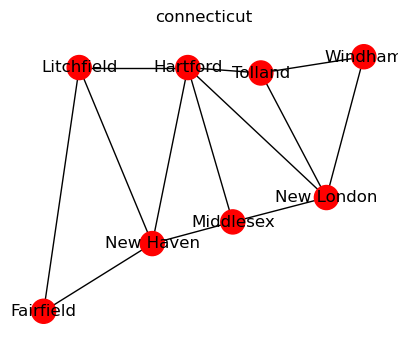

In [4]:
draw_map("connecticut", connecticut, (5, 4), [(n, "red") for n in connecticut["nodes"]])

This coloring obviously has some problems! You're going to write a program to fix it.

So what we (and by "we", I mean "you") would like to do is write a program that can figure out how to color a planar map...ie, `connecticut` *and* `europe`, you will do it by implementing a function that uses the algorithms that were discussed in this module.

## Which CSP Algorithms?

You will need to implement **backtracking** and **forward checking**. Look at the pseudocode for `backtracking_search` on p. 192 of AIAMA 4th Edition.

You *must* implement **Degree Heuristic** (to pick variables) and **Least Constraining Value** (to pick values).
You *may* implement **Minimum Remaining Values** as a tie breaker, if you like.
Otherwise, break ties in ascending order (least to most).
(Which functions in the pseudocode represent the heuristics?).

You should get the backtracking and forward checking implemented first. 
Then add the heuristics. 
You must use the pseudocode in the book and then stub out the functions that implement the "pick a variable" heuristic and the "pick a value" heuristic. 
When you get it working, fill in the appropriate heuristic mentioned above.

Please change the "?" below into "yes" or "no" indicating which elements you were able to implement:

```
Required:
    backtracking: Yes
    forward checking: Yes
    degree heuristic: Yes
    least contraining value: Yes
Optional:    
    minimum remaining values: Yes
```  

Your function should take the following form:

```python
def color_map( planar_map, color_list, trace=False)
```

where `planar_map` has the format described above, colors is a List of Strings denoting the colors to use and `trace` operates as described in the next paragraph. It should return a List of Tuples where each Tuple is of the form `( Node Name, Color)` in the same order as the `node` entry in the planar_map. For example, if we had `["A", "B"]` as nodes and `["Yellow", "Green"]` as colors, your function might return `[("A", "Yellow"), ("B", "Green")]`. If a coloring cannot be found, return `None`.

Your function also will take an optional argument, `trace`, with a default value of `False`.

If `trace` is set to `True` your program will print out *traces* (or debugging) statements that show what it is currently doing (in terms of the algorithms you are supposed to implement):

1. The variable selected and why.
2. The values proposed in order.
3. backtracking detected by forward checking (empty domains).

Don't print out a lot of noise.

As usual, you should implement your function using helper functions, using one Markdown cell for documentation and one Codecell for implementation (one function and assertions).

-----

<a id="get_neighbor_indices"></a>
## get_neighbor_indices

*`get_neighbor_indices` Given a list of edges and an index, find all nodes that share an edge with the index.* **Used by**: [get_domain](#get_domain), [degree_heuristic](#degree_heuristic), [constraint_value_overlaps](#constraint_value_overlaps) [least_constraining_value](#least_constraining_value), [is_value_consistent](#is_value_consistent) and [forward_checking](#forward_checking)

* **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
* **index** int - index of node to find edges of 

**returns** List[int] - a list of node indices that share an edge with the node at index

In [5]:
def get_neighbor_indices(edges: List[Tuple[int, int]], index: int) -> List[int]:
    neighbors: List[int] = []
    for edge in edges:
        if index == edge[0]:
            neighbors.append(edge[1])
        elif index == edge[1]:
            neighbors.append(edge[0])
    return neighbors

In [6]:
edges = [(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)]
assert get_neighbor_indices(edges, 0) == [1, 2, 3]  # test 1 - get edge nodes
assert get_neighbor_indices(edges, 4) == []  # test 2 - edge not in list returns empty list
assert get_neighbor_indices(edges, 1) == [0, 2]  # test 3 - get all edges no matter which position the index is in

<a id="minimum_remaining_value"></a>
## minimum_remaining_value

*`minimum_remaining_value` Given a list of nodes and a list of domains in a dictionary, find the node with smallest domain. Ties are broken by in ascending order.  If no nodes are left or all nodes are assigned (None, -1) is returned.* **Used by**: 

* **planar_map** Dict - a dict containing 2 key value pairs: 
    - **nodes**   List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains**  List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **assignments**  Dict[str, str] - map of nodes to colors
* **trace** bool - if true print debug information 

**returns** Tuple[str | None, int] - the node and its index with the smallest domain or None if all nodes are assigned

In [7]:
def minimum_remaining_value(planar_map: Dict, assignments: Dict[str, str], trace: bool = False) -> Tuple[str | None, int]:
    fewest_node, fewest_node_index, fewest_domain = None, -1, inf

    for index, node in enumerate(planar_map["nodes"]):
        if node in assignments:
            continue
        domain_size = len(planar_map["domains"][index])

        if domain_size < fewest_domain or (domain_size == fewest_domain and node < fewest_node):
            fewest_node = node
            fewest_domain = domain_size
            fewest_node_index = index

    if trace:
        print(f"Selected node {fewest_node} has smallest domain size ({fewest_domain}) and ", end="")
    return fewest_node, fewest_node_index

In [8]:
assert minimum_remaining_value({"nodes": ["a", "b", "c"], "domains": [[0], [0, 1, 2], [0, 1, 2, 3]]}, {}) == ("a", 0)  # test 1 get node/index of smallest domain
assert minimum_remaining_value({"nodes": ["b", "c", "a"], "domains": [[0], [0], [0]]}, {}) == ("a", 2)  # test 2 tie goes by ascending order od node value
assert minimum_remaining_value({"nodes": [], "domains": []}, {}) == (None, -1)  # test 3 - if nodes are all assigned or no nodes return None

<a id="degree_heuristic"></a>
## degree_heuristic

*`degree_heuristic` Given a list of nodes and a list of edges (in a dictionary), find the node with the most edges to other nodes (constraints). Ties are broken by choosing the variable with the smaller domain. If all nodes are assigned or no nodes can be find (None, -1) is returned* **Used by**: 

* **planar_map** Dict - a dict containing 2 key value pairs: 
    - **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
* **assignments**  Dict[str, str] - map of nodes to colors
* **trace** bool - if true print debug information 

**returns** Tuple[str | None, int] - the node and its index with the smallest domain, or (None, -1) on error

In [9]:
def degree_heuristic(planar_map: Dict, assignment: Dict[str, str], trace: bool = False) -> Tuple[str | None, int]:
    best_node = None
    best_node_index = -1
    most_constraints = 0
    for index, node in enumerate(planar_map["nodes"]):
        if node in assignment:
            continue
        
        n_edges = len(get_neighbor_indices(planar_map["edges"], index))
        if n_edges > most_constraints or (n_edges == most_constraints and len(planar_map["domains"][index]) < len(planar_map["domains"][best_node_index])):
            best_node = node
            most_constraints = n_edges
            best_node_index = index

    if trace:
        print(f"Selected node {best_node} has the most constraints ({most_constraints}) and ", end=" ")

    return best_node, best_node_index

In [10]:
m = {"nodes": ["a", "b", "c", "d"], "edges": [(0, 1), (0, 2), (1, 2), (0, 3)], "domains": [[1, 2, 3, 4], [1, 2, 3], [1, 2], [3, 4]]}
assert degree_heuristic(m, {}) == ("a", 0)  # test 1 - from sc, 'a' 3 edges, 'b' and 'c' have 2, 'd' has 1

m = {"nodes": ["a", "b", "c", "d"], "edges": [(0, 1), (0, 2), (1, 2), (0, 3)], "domains": [[1], [2, 3], [2], [3, 4]]}
assert degree_heuristic(m, {"a": 1}) == ("c", 2)  # test 2 - tie btw b and c is broken by mrv (c has 1 b has 2)

m = {"nodes": ["a", "b", "c", "d"], "edges": [(0, 1), (0, 2), (1, 2), (0, 3)], "domains": [[1], [2, 3], [2], [3, 4]]}
assert degree_heuristic(m, {"a": 1, "b": 3, "c": 2, "d": 4}) == (None, -1)  # test 3 - once all nodes assigned we return (None, -1)

<a id="constraint_value_overlaps"></a>
## constraint_value_overlaps

*`constraint_value_overlaps` Given dictionary with a list of edges and a list of domains (potential value for each node), a node's index and a value (color) compute the number of neighboring nodes that have color in their domain.* **Used by**: 

* **planar_map** Dict - a dict containing 2 key value pairs: 
    - **edges** List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains** List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **index** int - index of node to find overlaps with 
* **color** str - color value to find in neighboring domains

**returns** int - the number of neighbors to index that have color in their domain 

In [11]:
def constraint_value_overlaps(planar_map: Dict, index: int, color: str) -> int:
    overlapping = 0
    for neighbor in get_neighbor_indices(planar_map["edges"], index):
        if color in planar_map["domains"][neighbor]:
            overlapping += 1
    return overlapping

<a id="least_constraining_value"></a>
## least_constraining_value

*`least_constraining_value` given a dictionary with edges and domains, a nodes index and a list of colors, for each color find the number of neighboring nodes that have the color in its domain. Return a list of colors sorted by the number of overlapping neighbors.* **Used by**: 

* **planar_map** Dict - a dict containing 2 key value pairs: 
    - **edges** List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains** List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **index** int - index of node to find overlaps with 
* **color_list** List[str] - list of possible colors
* **trace** bool - if true print debug information 


**returns** List[str] - list of colors sorted by the number of overlapping neighbors

In [12]:
def least_constraining_value(planar_map: Dict, index: int, color_list: List[str], trace: bool = False) -> List[str]:  # pick val
    values = sorted(color_list, key=lambda x: constraint_value_overlaps(planar_map, index, x))
    if trace:
        print(f"domain values: {' '.join(values)}")
    return values

<a id="is_assignment_complete"></a>
## is_assignment_complete

*`is_assignment_complete` check if an assignment dictionary has an entry for each node in a list of nodes .* **Used by**: 

* **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge.*
* **assignments**  Dict[str, str] - map of nodes to colors


**returns** bool - is the assignment complete

In [13]:
def is_assignment_complete(nodes: List[str], assignments: Dict[str, str]) -> bool:  # correct number of assignments
    if sorted(assignments.keys()) != sorted(nodes):
        return False
    return True

<a id="is_value_consistent"></a>
## is_value_consistent

*`is_value_consistent` Given a list of nodes and a list of edges in a dictionary, check if a color if assigned to the neighbor of node at a given index.* **Used by**: 

* **planar_map** Dict - a dict containing 2 key value pairs: 
    - **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
* **index** int - index of node to check for consistency 
* **value** str - color 
* **assignments**  Dict[str, str] - map of nodes to colors


**returns** bool - can the value be assigned to the node

In [14]:
def is_value_consistent(planar_map: Dict, index: int, value: str, assignments: Dict[str, str]) -> bool:
    for neighbor_index in get_neighbor_indices(planar_map["edges"], index):
        neighbor = planar_map["nodes"][neighbor_index]
        if neighbor in assignments and assignments[neighbor] == value:
            return False
    return True

<a id="make_assignment"></a>
## make_assignment

*`make_assignment` add a variable to a dictionary of assignments with the specified color (value). Collapse the domain of the variable to just the assigned value, and add the assignment to the undo list.* **Used by**: [backtrack](#backtrack)

* **planar_map** Dict - a dict containing 3 key value pairs: 
    - **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains** List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **variable** str - node to forward check 
* **index** int - index of node to forward check
* **value** str - color to assign to node
* **assignments**  Dict[str, str] - map of nodes to colors
* **undo_list** List[Tuple[int, List[str]]] - a list of colors ruled out by assignments during the forward checking 


**returns** 

In [15]:
def make_assignment(planar_map: Dict, variable: str, index: int, value: str, assignments: Dict, undo_list: List[Tuple[int, List[str]]]):
    undo_list.append((index, [c for c in planar_map["domains"][index] if c != value]))
    planar_map["domains"][index] = [value]
    assignments[variable] = value
    return

<a id="forward_checking"></a>
## forward_checking

*`forward_checking` Given a potential assignment of node to color, check if any neighboring node domains could be reduced by removing color from it.* **Used by**: [backtrack](#backtrack)

* **planar_map** Dict - a dict containing 3 key value pairs: 
    - **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains** List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **variable** str - node to forward check 
* **index** int - index of node to forward check
* **value** str - color to assign to node
* **assignments**  Dict[str, str] - map of nodes to colors
* **undo_list** List[Tuple[int, List[str]]] - a list of colors ruled out by assignments during the forward checking 


**returns** 

In [ ]:
def forward_checking(planar_map: Dict, variable: str, index: int, value: str, assignments: Dict[str, str], undo_list: List[Tuple[int, List[str]]], trace: bool = False) -> Dict[int, List[str]] | None:
    inference = {}
    for neighbor_index in get_neighbor_indices(planar_map["edges"], index):
        neighbor = planar_map["nodes"][neighbor_index]
        if neighbor in assignments:
            continue
        domain: list[str] = planar_map["domains"][neighbor_index]
        if value not in domain:
            continue
        if len(domain) == 1:
            if trace:
                print(f"Backtracking detected - Assigning {variable} to {value} caused node {neighbor} to have empty domain")
            return None    
        inference[neighbor_index] = [i for i in domain if i != value]
    return inference


# def forward_checking(planar_map: Dict, variable: str, index: int, value: str, assignments: Dict[str, str], undo_list: List[Tuple[int, List[str]]], trace: bool = False) -> bool:
#     for neighbor_index in get_neighbor_indices(planar_map["edges"], index):
#         neighbor = planar_map["nodes"][neighbor_index]
#         if neighbor not in assignments:
#             if value in planar_map["domains"][neighbor_index]:
#                 planar_map["domains"][neighbor_index].remove(value)
#                 undo_list.append((neighbor_index, [value]))

#             if len(planar_map["domains"][neighbor_index]) == 0:  # unsolvable since node has empty domain
#                 if trace:
#                     print(f"Backtracking detected - Assigning {variable} to {value} caused node {neighbor} to have empty domain")
#                 return False
#     return True

<a id="undo_forward_checking"></a>
## undo_forward_checking

*`undo_forward_checking` back track assignment(s) that led to a node with anh empty domain.* **Used by**: [backtrack](#backtrack)

* **planar_map** Dict - a dict containing 3 key value pairs: 
    - **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains** List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **value** str - color to assign to node
* **undo_list** List[Tuple[int, List[str]]] - a list of colors ruled out by assignments during the forward checking 


**returns** 

In [17]:
def undo_forward_checking(planar_map: Dict, value: str, undo_list: List[Tuple[int, List[str]]]):  # reverse effect of forward_checking
    for index, values in undo_list:
        for value in values:
            if value not in planar_map["domains"][index]:
                planar_map["domains"][index].append(value)
    return

<a id="del_assignments"></a>
## del_assignments

*`del_assignments` remove an variable from assignments and check if the value returned is expected.* **Used by**: [backtrack](#backtrack)

* **variable** str - node to forward check 
* **value** str - color to assign to node
* **assignments**  Dict[str, str] - map of nodes to colors


**returns** bool - if variable was assigned to value in assignments

In [18]:
def del_assignments(variable: str, value: str, assignments: Dict) -> bool:
    if variable in assignments:
        c = assignments.pop(variable)
        if c != value:
            assignments[variable] = c
            return False
    return True

In [ ]:
def follow_inference(planar_map: Dict, vnode: str, vindex: int, value: str, color_list: List[str], assignments: Dict[str, str], get_variable: Callable, trace: bool = False) -> List[Tuple[str, str]] | None:
    undo_list: List[Tuple[int, List[str]]] = []
    make_assignment(planar_map, vnode, vindex, value, assignments, undo_list)
    
    if forward_checking(planar_map, vnode, vindex, value, assignments, undo_list, trace):  
        result = backtrack(planar_map, color_list, assignments, get_variable, trace)
        if result is not None:
            return result
        
    undo_forward_checking(planar_map, value, undo_list)
    if not del_assignments(vnode, value, assignments):
        raise Exception("Could not remove assignment {} -> {}".format(vnode, value))
    return None

<a id="backtrack"></a>
## backtrack

*`backtrack` .* **Uses**:

* **planar_map** Dict - a dict containing 3 key value pairs: 
    - **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains** List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **color_list** List[str] - list of possible colors
* **assignments**  Dict[str, str] - map of nodes to colors
* **get_variable** Callable - function that retrieves the next variable to try to assign. [ [minimum_remaining_value](#minimum_remaining_value) or [degree_heuristic](#degree_heuristic) ]
* **trace** bool - if true print debug information 


**returns** 

In [20]:
def backtrack(planar_map: Dict, color_list: List[str], assignments: Dict[str, str], get_variable: Callable, trace: bool = False) -> List[Tuple[str, str]] | None:
    if is_assignment_complete(planar_map["nodes"], assignments):
        return [(node, assignments[node]) for node in planar_map["nodes"]]

    vnode, vindex = get_variable(planar_map, assignments, trace)
    if vnode is None:
        raise Exception("Could not find variable to color")

    domain: List[str] = planar_map["domains"][vindex]
    for value in least_constraining_value(planar_map, vindex, domain, trace):
        if is_value_consistent(planar_map, vindex, value, assignments):            
            result = follow_inference(planar_map, vnode, vindex, value, color_list, assignments, get_variable, trace)
            if result is not None:
                return result

    return None

<a id="color_map"></a>
## color_map

*`color_map` .* **Uses**:

* **planar_map** Dict - a dict containing 3 key value pairs: 
    - **nodes**  List[str] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **edges**  List[Tuple[int,int]] - a list of edges, each edge is represented as tuple containing the indices of the 2 nodes that share an edge. 
    - **domains** List[List[str]], - a list of domains for each node. Each domain is a list of colors available to be assigned. 
* **color_list** List[str] - list of possible colors
* **get_variable** Callable - function that retrieves the next variable to try to assign. [ [minimum_remaining_value](#minimum_remaining_value) or [degree_heuristic](#degree_heuristic) ]
* **trace** bool - if true print debug information 


**returns** 

In [21]:
def color_map(planar_map: Dict, color_list: List[str], get_variable: Callable = degree_heuristic, trace: bool = False):
    planar_map["domains"] = [list(color_list) for _ in range(len(planar_map["nodes"]))]
    return backtrack(planar_map, color_list, {}, get_variable, trace)

Currently, it just colors everything red. When you are done, if it cannot find a coloring, it should return `None`.

## Problem 1. Color Connecticut Using Your Solution

In [22]:
connecticut_colors = color_map(connecticut, ["red", "blue", "green", "yellow"], trace=True)

Selected node Hartford has the most constraints (5) and  domain values: red blue green yellow
Selected node New Haven has the most constraints (4) and  domain values: blue green yellow
Selected node New London has the most constraints (4) and  domain values: blue green yellow
Selected node Litchfield has the most constraints (3) and  domain values: green yellow
Selected node Middlesex has the most constraints (3) and  domain values: green yellow
Selected node Tolland has the most constraints (3) and  domain values: green yellow
Selected node Fairfield has the most constraints (2) and  domain values: red yellow
Selected node Windham has the most constraints (2) and  domain values: red yellow


Using the "edges" list from the connecticut map, we can test to see if each pair of adjacent nodes is indeed colored differently:

<a id="four_ct"></a>
#### Test Cases

In [23]:
edges = connecticut["edges"]
nodes = connecticut["nodes"]
colors = connecticut_colors
COLOR = 1

for start, end in edges:
    try:
        assert colors[start][COLOR] != colors[end][COLOR]
    except AssertionError as err:
        print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")
        raise err

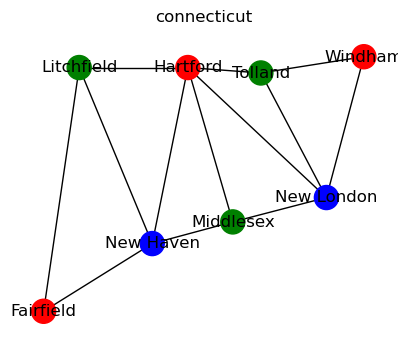

In [24]:
draw_map("connecticut", connecticut, (5, 4), connecticut_colors)

<a id="three_ct"></a>
## Does the Four Color Theorem apply here?

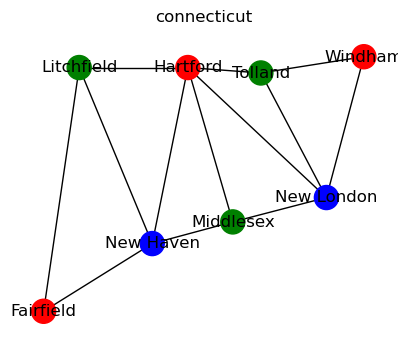

In [25]:
connecticut_colors = color_map(connecticut, ["red", "blue", "green"], trace=False)
if connecticut_colors:
    draw_map("connecticut", connecticut, (5, 4), connecticut_colors)

yes, the four color theorem applies here, even though only three colors were provided, since it is a cubic map (each node connects to 3 other nodes) and each node can alternate coloring of 3 colors. 

## Problem 2. Color Europe Using Your solution

In [26]:
# fmt: off
europe = {
    'coordinates': [(47, 28), (108, 14), (18, 147), (48, 83), (98, 59), (148, 57),
                 (160, 13), (63, 34), (84, 80), (82, 69), (136, 95), (194, 32),
                 (94, 97), (143, 149), (140, 111), (110, 67), (127, 40),
                 (118, 47), (111, 54), (189, 39), (202, 33), (82, 74),
                 (110, 162), (137, 102), (93, 55), (125, 32), (128, 37),
                 (122, 42), (116, 53), (124, 65), (146, 87), (138, 54),
                 (137, 41), (64, 90), (130, 22), (168, 29), (78, 55),
                 (116, 144), (122, 57), (158, 65), (122, 78), (112, 60),
                 (127, 48), (191, 118), (100, 78), (102, 35)],
 'edges': [(2, 3), (2, 33), (3, 33), (33, 36), (33, 21), (33, 8), (33, 22),
           (0, 7), (7, 36), (7, 45), (36, 21), (36, 9), (36, 44), (36, 24),
           (36, 45), (21, 8), (21, 9), (21, 44), (8, 44), (9, 44), (44, 12),
           (44, 37), (44, 40), (44, 15), (44, 41), (44, 24), (12, 22), (12, 37),
           (12, 40), (22, 37), (22, 13), (22, 43), (37, 13), (37, 14), (37, 23),
           (37, 40), (13, 14), (13, 43), (14, 23), (14, 43), (23, 10), (23, 30),
           (23, 43), (10, 40), (10, 30), (40, 15), (40, 29), (40, 30), (40, 39),
           (15, 41), (15, 29), (41, 4), (41, 24), (41, 45), (41, 18), (41, 38),
           (41, 29), (4, 24), (24, 45), (45, 1), (45, 34), (45, 25), (45, 27),
           (45, 17), (45, 28), (45, 18), (34, 25), (34, 26), (34, 32), (34, 6),
           (34, 35), (25, 26), (25, 16), (25, 27), (26, 16), (26, 42), (26, 32),
           (16, 27), (16, 42), (27, 17), (27, 42), (17, 42), (17, 28), (42, 28),
           (42, 38), (42, 31), (42, 32), (28, 18), (28, 38), (18, 38), (38, 29),
           (38, 39), (38, 31), (29, 39), (30, 39), (30, 43), (39, 5), (39, 31),
           (39, 43), (5, 31), (31, 32), (32, 35), (6, 35), (35, 19), (35, 11),
           (35, 20), (19, 11), (19, 20), (19, 43), (11, 20), (20, 43)],
 'nodes': ['Portugal', 'Malta', 'Iceland', 'Ireland', 'Liechtenstein',
           'Moldova', 'Cyprus', 'Spain', 'Netherlands', 'Luxembourg',
           'Lithuania', 'Armenia', 'Denmark', 'Finland', 'Estonia',
           'Czech Republic', 'Kosovo', 'Bosnia Herzegovina', 'Slovenia',
           'Georgia', 'Azerbaijan', 'Belgium', 'Norway', 'Latvia',
           'Switzerland', 'Albania', 'Macedonia', 'Montenegro', 'Croatia',
           'Slovakia', 'Belarus', 'Romania', 'Bulgaria', 'United Kingdom',
           'Greece', 'Turkey', 'France', 'Sweden', 'Hungary', 'Ukraine',
           'Poland', 'Austria', 'Serbia', 'Russia', 'Germany', 'Italy']}
print(europe)
# fmt: on

{'coordinates': [(47, 28), (108, 14), (18, 147), (48, 83), (98, 59), (148, 57), (160, 13), (63, 34), (84, 80), (82, 69), (136, 95), (194, 32), (94, 97), (143, 149), (140, 111), (110, 67), (127, 40), (118, 47), (111, 54), (189, 39), (202, 33), (82, 74), (110, 162), (137, 102), (93, 55), (125, 32), (128, 37), (122, 42), (116, 53), (124, 65), (146, 87), (138, 54), (137, 41), (64, 90), (130, 22), (168, 29), (78, 55), (116, 144), (122, 57), (158, 65), (122, 78), (112, 60), (127, 48), (191, 118), (100, 78), (102, 35)], 'edges': [(2, 3), (2, 33), (3, 33), (33, 36), (33, 21), (33, 8), (33, 22), (0, 7), (7, 36), (7, 45), (36, 21), (36, 9), (36, 44), (36, 24), (36, 45), (21, 8), (21, 9), (21, 44), (8, 44), (9, 44), (44, 12), (44, 37), (44, 40), (44, 15), (44, 41), (44, 24), (12, 22), (12, 37), (12, 40), (22, 37), (22, 13), (22, 43), (37, 13), (37, 14), (37, 23), (37, 40), (13, 14), (13, 43), (14, 23), (14, 43), (23, 10), (23, 30), (23, 43), (10, 40), (10, 30), (40, 15), (40, 29), (40, 30), (40, 

In [27]:
europe_colors = color_map(europe, ["red", "blue", "green", "yellow"], trace=True)

Selected node Italy has the most constraints (11) and  domain values: red blue green yellow
Selected node Germany has the most constraints (10) and  domain values: red blue green yellow
Selected node Poland has the most constraints (8) and  domain values: blue green yellow
Selected node Austria has the most constraints (8) and  domain values: blue green yellow
Selected node Serbia has the most constraints (8) and  domain values: red blue green yellow
Selected node Russia has the most constraints (8) and  domain values: blue red green yellow
Selected node Sweden has the most constraints (7) and  domain values: green yellow
Selected node Hungary has the most constraints (7) and  domain values: green yellow
Selected node Ukraine has the most constraints (7) and  domain values: red yellow
Selected node France has the most constraints (7) and  domain values: blue green yellow
Selected node United Kingdom has the most constraints (6) and  domain values: red green yellow
Selected node Greece 

Here we're testing to see if the adjacent nodes are colored differently:

<a id="four_eu"></a>
#### Test Cases

In [28]:
edges = europe["edges"]
nodes = europe["nodes"]
colors = europe_colors
COLOR = 1
assert colors is not None

for start, end in edges:
    try:
        assert colors[start][COLOR] != colors[end][COLOR]
    except AssertionError as err:
        print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")
        raise err

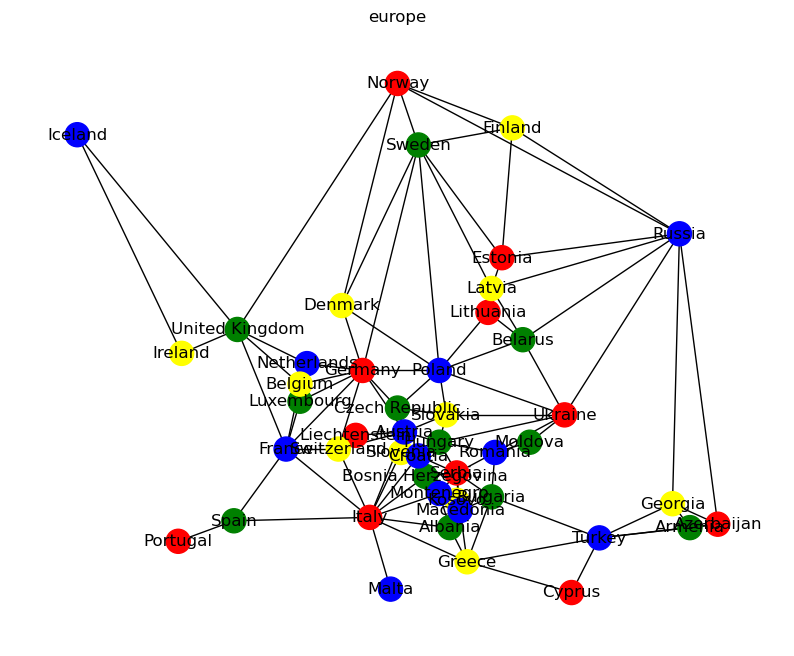

In [29]:
draw_map("europe", europe, (10, 8), europe_colors)

<a id="three_eu"></a>
## Does the Four Color Theorem apply here?

In [30]:
europe_colors = color_map(europe, ["red", "blue", "green"], trace=False)
print(europe_colors)
if europe_colors:
    draw_map("europe", europe, (10, 8), europe_colors)

None


## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.